# Assignment 04 — LSTM Weather Time-Series Forecasting

### Forecasting setup

- **Dataset:** Jena Climate weather observations
- **Target:** `T (degC)` — air temperature
- **Input features:** air temperature, pressure, relative humidity, and wind velocity
- **Original frequency:** 10 minutes
- **Working frequency:** 1 hour, obtained by hourly averaging
- **Sequence length:** previous 24 hourly observations
- **Prediction horizon:** next 1 hour
- **Split:** chronological 80% training / 20% testing
- **Evaluation:** MAE and RMSE

> Time order is preserved throughout the experiment. Random train-test shuffling is intentionally avoided because it can leak future information into the training process.

## 1. Import Libraries

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. Load and Inspect the Dataset

In [ ]:
DATA_PATH = "jena_climate_2009_2016.csv"

df = pd.read_csv(DATA_PATH)

df["Date Time"] = pd.to_datetime(
    df["Date Time"],
    format="%d.%m.%Y %H:%M:%S"
)

df = df.sort_values("Date Time").reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Start:", df["Date Time"].min())
print("End:", df["Date Time"].max())
print("Missing values:", df.isna().sum().sum())

display(df.head())

Dataset shape: (420551, 15)
Start: 2009-01-01 00:10:00
End: 2017-01-01 00:00:00
Missing values: 0


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


### Dataset overview

The supplied dataset contains weather observations recorded at 10-minute intervals. The timestamp column is used to preserve chronological order, while the numerical weather measurements provide candidate predictors for temperature forecasting.


## 3. Select Features and Convert to Hourly Data

In [ ]:
# Relevant variables for a compact multivariate forecasting model.
FEATURES = ["T (degC)", "p (mbar)", "rh (%)", "wv (m/s)"]
TARGET = "T (degC)"

weather = df[["Date Time"] + FEATURES].copy()

# Aggregate the 10-minute observations into hourly averages.
hourly = (
    weather.set_index("Date Time")
           .resample("1h")
           .mean()
           .dropna()
           .reset_index()
)

print("Hourly dataset shape:", hourly.shape)
display(hourly.head())


Hourly dataset shape: (70041, 5)


,Date Time,T (degC),p (mbar),rh (%),wv (m/s)
0,2009-01-01 00:00:00,-8.304000,996.528000,93.780000,0.520000
1,2009-01-01 01:00:00,-8.065000,996.525000,93.933333,0.316667
2,2009-01-01 02:00:00,-8.763333,996.745000,93.533333,0.248333
3,2009-01-01 03:00:00,-8.896667,996.986667,93.200000,0.176667
4,2009-01-01 04:00:00,-9.348333,997.158333,92.383333,0.290000


Hourly resampling reduces the number of training windows while retaining the short-term temperature and weather dynamics needed for a practical LSTM demonstration.


## 4. Visualize Temperature

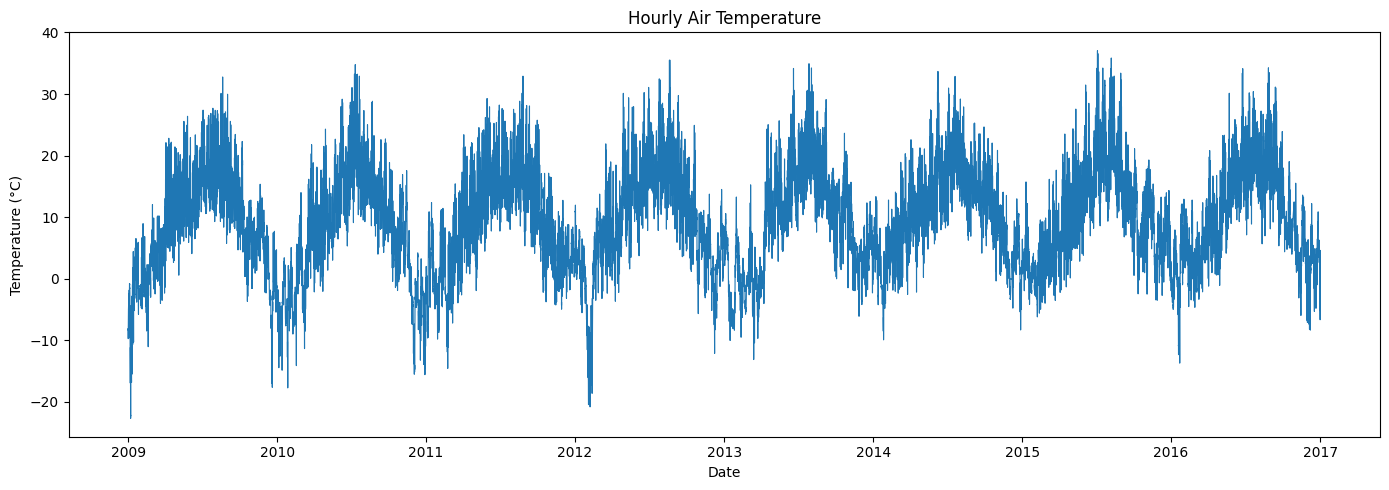

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(hourly["Date Time"], hourly[TARGET], linewidth=0.8)
plt.title("Hourly Air Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()


## 5. Chronological Train-Test Split

In [ ]:
split_idx = int(len(hourly) * 0.80)

train_df = hourly.iloc[:split_idx].copy()
test_df = hourly.iloc[split_idx:].copy()

print("Training rows:", len(train_df))
print("Testing rows :", len(test_df))
print("Training period:", train_df["Date Time"].min(), "to", train_df["Date Time"].max())
print("Testing period :", test_df["Date Time"].min(), "to", test_df["Date Time"].max())


Training rows: 56032
Testing rows : 14009
Training period: 2009-01-01 00:00:00 to 2015-05-25 06:00:00
Testing period : 2015-05-25 07:00:00 to 2017-01-01 00:00:00


The split is chronological rather than random: earlier observations are used for training and later observations are reserved for testing. This matches the real forecasting scenario.


## 6. Normalize the Features

In [ ]:
feature_scaler = StandardScaler()

train_values = train_df[FEATURES].values
test_values = test_df[FEATURES].values

train_scaled = feature_scaler.fit_transform(train_values)
test_scaled = feature_scaler.transform(test_values)

print("Training scaled shape:", train_scaled.shape)
print("Testing scaled shape :", test_scaled.shape)


Training scaled shape: (56032, 4)
Testing scaled shape : (14009, 4)


The scaler is fitted **only on the training data**. The test set is transformed using the training statistics to avoid information leakage.


## 7. Create LSTM Sequences

In [ ]:
SEQUENCE_LENGTH = 24  # previous 24 hours -> predict the next hour

target_index = FEATURES.index(TARGET)

def create_sequences(data, sequence_length, target_index):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])
        y.append(data[i, target_index])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(
    train_scaled, SEQUENCE_LENGTH, target_index
)

# Include the final 24 training observations as context for the first test prediction.
test_context = np.vstack([train_scaled[-SEQUENCE_LENGTH:], test_scaled])

X_test, y_test = create_sequences(
    test_context, SEQUENCE_LENGTH, target_index
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


X_train: (56008, 24, 4)
y_train: (56008,)
X_test : (14009, 24, 4)
y_test : (14009,)


Each input sample contains **24 consecutive hourly observations**. The LSTM therefore receives a 24 × 4 sequence and predicts the temperature at the following hour.


## 8. Build the LSTM Model

In [ ]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(SEQUENCE_LENGTH, len(FEATURES))),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,777 (77.25 KB)

 Trainable params: 19,777 (77.25 KB)

 Non-trainable params: 0 (0.00 B)

### Model architecture

**Input (24 × 4) → LSTM (64 units) → Dense (32, ReLU) → Dense (1)**

The final single neuron produces the next-hour temperature prediction. Mean squared error is used as the training loss because this is a regression problem.


## 9. Train the Model

In [ ]:
EPOCHS = 10
BATCH_SIZE = 64

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.10,
    shuffle=False,
    verbose=1
)


Epoch 1/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0873 - mae: 0.1944 - val_loss: 0.0254 - val_mae: 0.1262
Epoch 2/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0179 - mae: 0.1001 - val_loss: 0.0166 - val_mae: 0.1018
Epoch 3/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0117 - mae: 0.0803 - val_loss: 0.0115 - val_mae: 0.0837
Epoch 4/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0084 - mae: 0.0671 - val_loss: 0.0084 - val_mae: 0.0705
Epoch 5/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0072 - mae: 0.0620 - val_loss: 0.0098 - val_mae: 0.0770
Epoch 6/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0065 - mae: 0.0584 - val_loss: 0.0073 - val_mae: 0.0657
Epoch 7/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0058 - mae: 0.0544 - val_loss: 0.0069 - val_mae: 0.0638
Epoch 8/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0056 - mae: 0.0531 - val_loss: 0.0056 - val_mae: 0.0558
Epoch 9/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - 

## 10. Training and Validation Curves

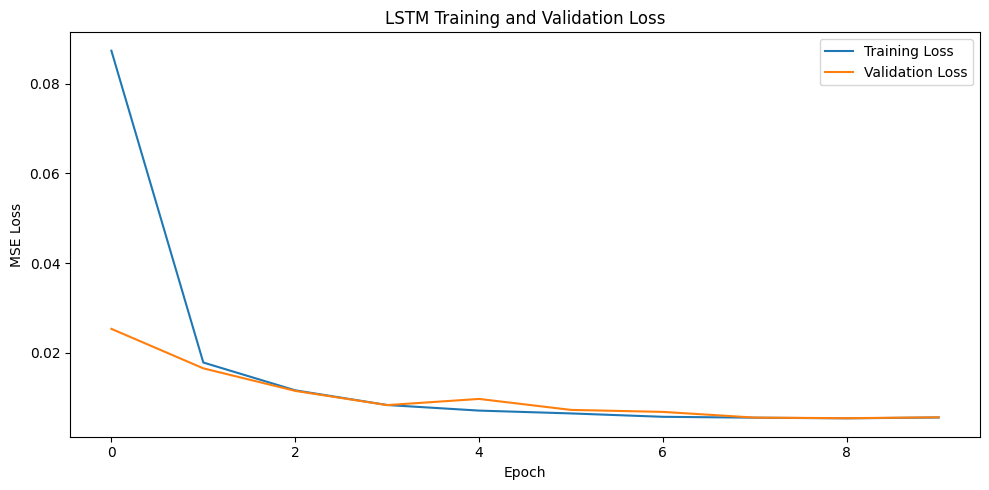

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Evaluate on the Test Set

In [ ]:
y_pred_scaled = model.predict(X_test, verbose=0).ravel()

# Convert scaled target values back to °C.
target_mean = feature_scaler.mean_[target_index]
target_scale = feature_scaler.scale_[target_index]

y_test_actual = y_test * target_scale + target_mean
y_pred_actual = y_pred_scaled * target_scale + target_mean

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print(f"Test MAE : {mae:.4f} °C")
print(f"Test RMSE: {rmse:.4f} °C")


Test MAE : 0.5398 °C
Test RMSE: 0.7577 °C


## 12. Actual vs Predicted Temperature

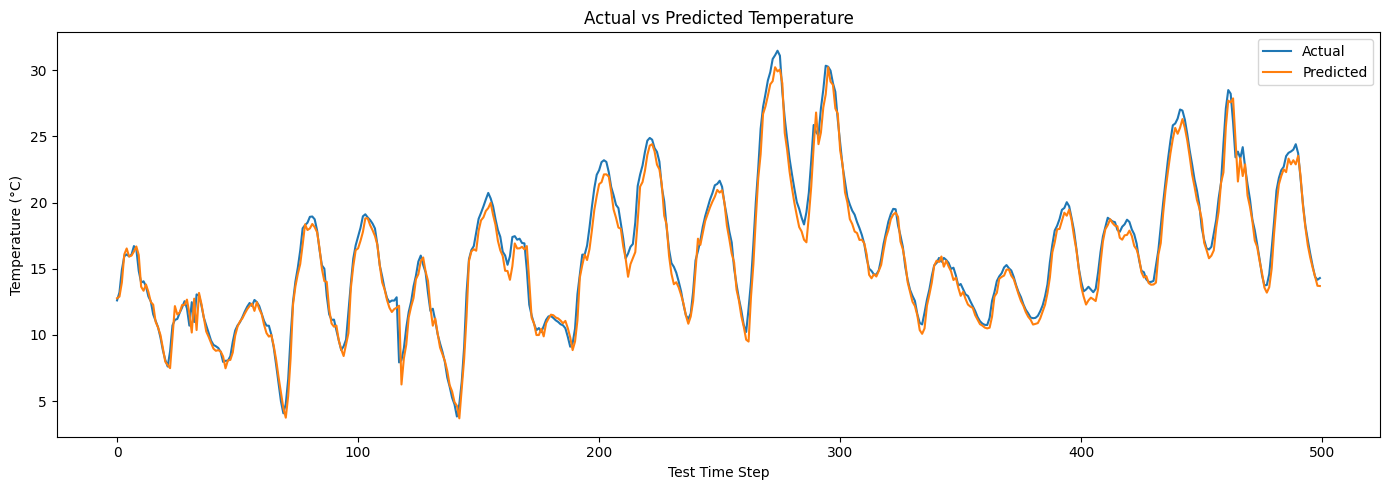

In [ ]:
# Plot a representative portion of the test period for readability.
plot_points = min(500, len(y_test_actual))

plt.figure(figsize=(14, 5))
plt.plot(y_test_actual[:plot_points], label="Actual")
plt.plot(y_pred_actual[:plot_points], label="Predicted")
plt.title("Actual vs Predicted Temperature")
plt.xlabel("Test Time Step")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Sample Predictions

In [ ]:
results = pd.DataFrame({
    "Actual Temperature (°C)": y_test_actual[:10],
    "Predicted Temperature (°C)": y_pred_actual[:10]
})

display(results.round(3))


,Actual Temperature (°C),Predicted Temperature (°C)
0,12.605,12.768
1,13.210,12.891
2,14.907,13.958
3,15.942,16.078
4,16.082,16.530
5,15.932,15.918
6,16.065,15.990
7,16.710,16.295
8,16.483,16.681
9,14.832,16.038


## 14. Conclusion

The LSTM model uses the temporal relationship among recent weather observations to forecast the next-hour air temperature. Performance is evaluated using MAE and RMSE, while the actual-versus-predicted plot provides a visual check of forecasting behavior.

Run all cells to generate the final numerical results for the current environment.
